In [1]:
# --- 1. LIBRARIES ---
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, auc)

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Dense, Conv1D, BatchNormalization, 
                                     concatenate, Flatten, Dropout, Attention, 
                                     Reshape, GlobalAveragePooling1D, Multiply, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:

# --- 2. REPRODUCIBILITY (The "Same Result" Rule) ---
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    print(f"Environment seeds locked at {seed}")

set_seeds(42)

Environment seeds locked at 42


In [3]:
# Load the specific binary dataset
df = pd.read_csv("leave_Caida2007.csv", engine="pyarrow")

# Verify the load by checking the total rows and columns
print(f"Dataset successfully loaded.")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset successfully loaded.
Total Rows: 100668668
Total Columns: 84


In [4]:
# 1. Strip any leading/trailing whitespace and convert to lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Replace spaces, slashes, and dots with underscores for easy coding
df.columns = df.columns.str.replace(' ', '_', regex=False)
df.columns = df.columns.str.replace('/', '_', regex=False)
df.columns = df.columns.str.replace('.', '_', regex=False)

# 3. Print the first 10 columns to verify the change
print("First 10 standardized columns:")
print(df.columns[:10].tolist())

# 4. Find the exact name of your Label column
label_col = [col for col in df.columns if 'label' in col]
print(f"\nLabel column found: {label_col}")

First 10 standardized columns:
['flow_id', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'timestamp', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts']

Label column found: ['label']


In [5]:
# List of columns that are not useful for training features
identifiers = ['flow_id', 'src_ip', 'dst_ip', 'timestamp']

# Drop them only if they exist in the current dataframe
df.drop(columns=[col for col in identifiers if col in df.columns], inplace=True)

print(f"Identifiers removed.")
print(f"Remaining columns: {df.shape[1]}")

Identifiers removed.
Remaining columns: 80


In [6]:
df.shape

(100668668, 80)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100668668 entries, 0 to 100668667
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   src_port           float64
 1   dst_port           float64
 2   protocol           float64
 3   flow_duration      float64
 4   tot_fwd_pkts       float64
 5   tot_bwd_pkts       float64
 6   totlen_fwd_pkts    float64
 7   totlen_bwd_pkts    float64
 8   fwd_pkt_len_max    float64
 9   fwd_pkt_len_min    float64
 10  fwd_pkt_len_mean   float64
 11  fwd_pkt_len_std    float64
 12  bwd_pkt_len_max    float64
 13  bwd_pkt_len_min    float64
 14  bwd_pkt_len_mean   float64
 15  bwd_pkt_len_std    float64
 16  flow_byts_s        float64
 17  flow_pkts_s        float64
 18  flow_iat_mean      float64
 19  flow_iat_std       float64
 20  flow_iat_max       float64
 21  flow_iat_min       float64
 22  fwd_iat_tot        float64
 23  fwd_iat_mean       float64
 24  fwd_iat_std        float64
 25  fwd_iat_max   

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['label'].value_counts()

label
1    88773176
0     9594880
Name: count, dtype: int64

In [10]:
import joblib
import numpy as np

imputer_bundle = joblib.load("regression_imputer.pkl")

imputer_models = imputer_bundle['models']
COLS_WONA = imputer_bundle['cols_wona']
COLS_WNA = imputer_bundle['cols_wna']


In [11]:
# Replace Inf with NaN (same as training)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [12]:
print("Remaining NaNs:", df.isna().sum().sum())

Remaining NaNs: 2794432


In [13]:
import gc

chunk_size = 5_000_000

for target_col, model in imputer_models.items():
    if target_col not in df.columns:
        continue  # safety check

    # Get indices of missing values
    predict_idx = df.index[df[target_col].isna()]
    
    if len(predict_idx) > 0:
        print(f"Applying predictions for: {target_col}")
        
        # Predict and fill in chunks
        for i in range(0, len(predict_idx), chunk_size):
            idx_chunk = predict_idx[i : i + chunk_size]
            X_pred_chunk = df.loc[idx_chunk, COLS_WONA].values
            
            preds = model.predict(X_pred_chunk)
            df.loc[idx_chunk, target_col] = preds
            
            del X_pred_chunk, preds
            
    # Force RAM cleanup after each column
    gc.collect()

Applying predictions for: flow_byts_s


C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Applying predictions for: flow_pkts_s


C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
print("Remaining NaNs:", df.isna().sum().sum())


Remaining NaNs: 0


In [15]:
# 1. Check for any columns that are not integers or floats (excluding 'label')
non_numeric = df.drop(columns=['label']).select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Non-numeric columns found (excluding label): {non_numeric}")

# 2. Check for Infinite values (common in this dataset)
inf_count = np.isinf(df.select_dtypes(include=[np.number])).values.sum()
print(f"Total Infinite values: {inf_count}")

# 3. Check for Null/NaN values
nan_count = df.isnull().sum().sum()
print(f"Total NaN values: {nan_count}")

Non-numeric columns found (excluding label): []
Total Infinite values: 0
Total NaN values: 0


In [16]:
# 1. Check unique values in the label column
print("Unique labels in dataset:")
print(df['label'].unique())

# 2. Check the count of each label to see if it is imbalanced
print("\nLabel counts:")
print(df['label'].value_counts())

# 3. Check the data type of the label
print(f"\nLabel data type: {df['label'].dtype}")

Unique labels in dataset:
[1 0]

Label counts:
label
1    88773176
0     9594880
Name: count, dtype: int64

Label data type: int64


In [17]:
import gc
import joblib

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['label'])
y = df['label']

# CLEAR RAM: Original dataframe is no longer needed
del df
gc.collect()

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CLEAR RAM: X is no longer needed
del X
gc.collect()

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")

scaler = joblib.load("scaler.pkl")
print("Scaler loaded successfully")

X_train_scaled = scaler.transform(X_train)
# CLEAR RAM: Delete unscaled X_train
del X_train
gc.collect()

X_test_scaled = scaler.transform(X_test)
# CLEAR RAM: Delete unscaled X_test
del X_test
gc.collect()

print(f"Scaling Complete. RAM cleaned.")
print(f"Train dtype: {X_train_scaled.dtype}")
print(f"Train shape: {X_train_scaled.shape}")

Training set: 78694444 rows
Testing set:  19673612 rows
Scaler loaded successfully
Scaling Complete. RAM cleaned.
Train dtype: float64
Train shape: (78694444, 79)


In [18]:
from tensorflow.keras.models import load_model

# Load encoder (for feature extraction)
encoder_only = load_model("AE_Encoder_Extractor.keras")

# (Optional) Load full autoencoder if you need reconstruction
autoencoder = load_model("AE_Stage1_Full.keras")

print("Models loaded successfully")



Models loaded successfully


In [19]:
# 1. Do reconstruction check FIRST while scaled data is still in RAM
X_train_recon = autoencoder.predict(X_train_scaled[:1000])
recon_error = np.mean(np.abs(X_train_scaled[:1000] - X_train_recon))
print("Reconstruction MAE:", recon_error)

# 2. Extract 32 latent features for training data
X_train_encoded = encoder_only.predict(X_train_scaled, batch_size=1024)

# CLEAR RAM: Delete the massive scaled training data!
import gc
del X_train_scaled
gc.collect()

# 3. Extract 32 latent features for testing data
X_test_encoded = encoder_only.predict(X_test_scaled, batch_size=1024)

# CLEAR RAM: Delete the scaled testing data!
del X_test_scaled
gc.collect()

print("Encoded shapes:")
print(X_train_encoded.shape)  # (samples, 32)
print(X_test_encoded.shape)

# 4. Reshape for CNN
X_train_cnn = X_train_encoded.reshape(-1, 32, 1)
X_test_cnn = X_test_encoded.reshape(-1, 32, 1)

print("CNN-ready shapes:")
print(X_train_cnn.shape)
print(X_test_cnn.shape)

 1/32 ━━━━━━━━━━━━━━━━━━━━ 11s 375ms/step

C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Reconstruction MAE:

C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


 0.0012487036687478187
   54/76851 ━━━━━━━━━━━━━━━━━━━━ 2:38 2ms/step

C:\Users\Cloud-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1024, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


76851/76851 ━━━━━━━━━━━━━━━━━━━━ 177s 2ms/step
19213/19213 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step
Encoded shapes:
(78694444, 32)
(19673612, 32)
CNN-ready shapes:
(78694444, 32, 1)
(19673612, 32, 1)


In [20]:
# --- CNN CLASSIFIER ARCHITECTURE ---

# Input shape is (32, 1) based on the 32 features extracted by the Autoencoder
inp = Input(shape=(X_train_cnn.shape[1], 1), name="CIAM_Input")

# Inception Module: Three parallel branches with 16 filters each
conv1 = Conv1D(16, 1, activation='relu', padding='same', name="Branch_1x1")(inp)
conv3 = Conv1D(16, 3, activation='relu', padding='same', name="Branch_3x3")(inp)
conv5 = Conv1D(16, 5, activation='relu', padding='same', name="Branch_5x5")(inp)

# Merge the branches: 16 + 16 + 16 = 48 total filters
merged = concatenate([conv1, conv3, conv5], axis=-1, name="Inception_Merge")
merged = BatchNormalization(name="Merge_BN")(merged)

# Attention Mechanism: Global Average Pooling -> Dense Weighting -> Multiply
gap = GlobalAveragePooling1D(name="Attention_GAP")(merged)
att_weights = Dense(48, activation='sigmoid', name="Attention_Weights")(gap)
att_weights = Reshape((1, 48), name="Attention_Reshape")(att_weights)
merged_att = tf.keras.layers.Multiply(name="Attention_Apply")([merged, att_weights])

# Classification Head
pooled = tf.keras.layers.MaxPooling1D(pool_size=2, name="Final_Pool")(merged_att)
flat = Flatten(name="Final_Flatten")(pooled)
x = Dense(16, activation='relu', name="Dense_16")(flat)
x = Dropout(0.1, name="Dropout_1")(x)
x = Dense(8, activation='relu', name="Dense_8_A")(x)
x = Dropout(0.1, name="Dropout_2")(x)
x = Dense(8, activation='relu', name="Dense_8_B")(x)

# Output: 2 units for Softmax classification
output = Dense(2, activation='softmax', name="Output_Layer")(x)

# Create the Model object
cnn_binary = Model(inp, output, name="CIAM_Binary_Classifier")

# Display the summary to verify the layers
cnn_binary.summary()

Model: "CIAM_Binary_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ CIAM_Input (InputLayer)       │ (None, 32, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Branch_1x1 (Conv1D)           │ (None, 32, 16)            │              32 │ CIAM_Input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Branch_3x3 (Conv1D)           │ (None, 32, 16)            │              64 │ CIAM_Input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Branch_5x5 (Conv1D)           │ (None, 32, 16)            │              96 │ CIAM_Input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Inception_Merge (Concatenate) │ (None, 32, 48)            │               0 │ Branch_1x1[0][0],          │
│                               │                           │                 │ Branch_3x3[0][0],          │
│                               │                           │                 │ Branch_5x5[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Merge_BN (BatchNormalization) │ (None, 32, 48)            │             192 │ Inception_Merge[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_GAP                 │ (None, 48)                │               0 │ Merge_BN[0][0]             │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_Weights (Dense)     │ (None, 48)                │           2,352 │ Attention_GAP[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_Reshape (Reshape)   │ (None, 1, 48)             │               0 │ Attention_Weights[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_Apply (Multiply)    │ (None, 32, 48)            │               0 │ Merge_BN[0][0],            │
│                               │                           │                 │ Attention_Reshape[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Final_Pool (MaxPooling1D)     │ (None, 16, 48)            │               0 │ Attention_Apply[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Final_Flatten (Flatten)       │ (None, 768)               │               0 │ Final_Pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Dense_16 (Dense)              │ (None, 16)                │          12,304 │ Final_Flatten[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Dropout_1 (Dropout)           │ (None, 16)                │               0 │ Dense_16[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Dense_8_A (Dense)             │ (None, 8)                 │             136 │ Dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 15,266 (59.63 KB)

 Trainable params: 15,170 (59.26 KB)

 Non-trainable params: 96 (384.00 B)

In [21]:
print("y_train type:", type(y_train))
print("y_train shape:", getattr(y_train, 'shape', 'N/A'))
print("y_train head / first 10 values:")
print(y_train.head() if hasattr(y_train, 'head') else y_train[:10])

print("\ny_test type:", type(y_test))
print("y_test shape:", getattr(y_test, 'shape', 'N/A'))
print("y_test head / first 10 values:")
print(y_test.head() if hasattr(y_test, 'head') else y_test[:10])


y_train type: <class 'pandas.core.series.Series'>
y_train shape: (78694444,)
y_train head / first 10 values:
36729552    1
90022165    1
80536623    1
44954066    1
10583836    1
Name: label, dtype: int64

y_test type: <class 'pandas.core.series.Series'>
y_test shape: (19673612,)
y_test head / first 10 values:
100155773    0
71264686     1
3737256      1
47404324     1
70600053     1
Name: label, dtype: int64


In [22]:
# 1. Compile the model
cnn_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Define the training callbacks
callbacks = [
    EarlyStopping(
        patience=5, 
        restore_best_weights=True, 
        monitor='val_accuracy'
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-7, 
        verbose=1
    )
]

# 3. Start training
print("Starting CIAM Classifier Training...")
history_cnn = cnn_binary.fit(
    X_train_cnn, y_train,
    epochs=5,
    batch_size=1024,
    validation_data=(X_test_cnn, y_test),
    callbacks=callbacks,
    verbose=1
)

Starting CIAM Classifier Training...
Epoch 1/5
76851/76851 ━━━━━━━━━━━━━━━━━━━━ 4269s 55ms/step - accuracy: 0.9971 - loss: 0.0092 - val_accuracy: 0.9991 - val_loss: 0.0025 - learning_rate: 1.0000e-04
Epoch 2/5
76851/76851 ━━━━━━━━━━━━━━━━━━━━ 3893s 51ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9992 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 3/5
76851/76851 ━━━━━━━━━━━━━━━━━━━━ 3932s 51ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0020 - learning_rate: 1.0000e-04
Epoch 4/5
76851/76851 ━━━━━━━━━━━━━━━━━━━━ 3836s 50ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9993 - val_loss: 0.0019 - learning_rate: 1.0000e-04
Epoch 5/5
51708/76851 ━━━━━━━━━━━━━━━━━━━━ 19:35 47ms/step - accuracy: 0.9992 - loss: 0.0022

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [23]:
cnn_binary.save("CIAM_CNN_Classifier.keras")
print("CNN model saved successfully")


CNN model saved successfully


In [24]:
cnn_binary = load_model("CIAM_CNN_Classifier.keras")

In [25]:
# 1. Predict on the test set
# np.argmax converts the Softmax output (probabilities for 0 and 1) into the final class (0 or 1)
y_pred_probs = cnn_binary.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Print Accuracy and Classification Report
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'ATTACK']))

# 3. Print Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


122136/614801 ━━━━━━━━━━━━━━━━━━━━ 12:36 2ms/step

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



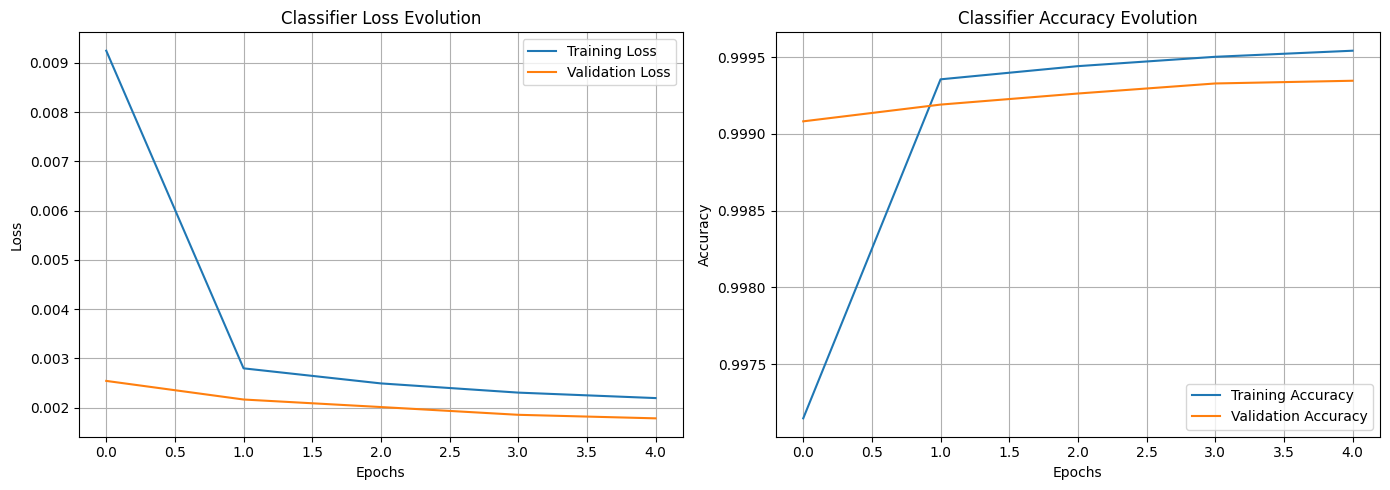

In [26]:
# Create a figure with two subplots
plt.figure(figsize=(14, 5))

# 1. Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Classifier Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Classifier Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

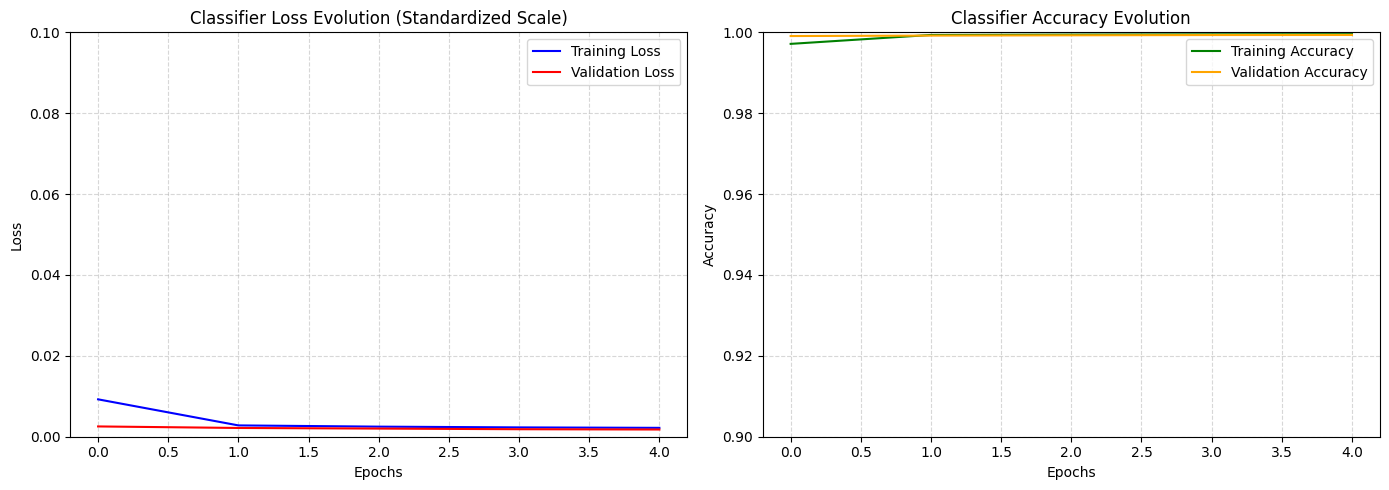

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Plot Loss with an increased Y-axis range
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss', color='blue')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', color='red')

# --- INCREASE SCALE HERE ---
# By setting the bottom to 0 and top to 0.1, 
# the 0.032 to 0.037 fluctuations will look like a much flatter line.
plt.ylim(0, 0.1) 

plt.title('Classifier Loss Evolution (Standardized Scale)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Plot Accuracy (Zoomed for detail)
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', color='orange')

# Standard accuracy scale to see the trend without excessive deflection
plt.ylim(0.9, 1.0) 

plt.title('Classifier Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

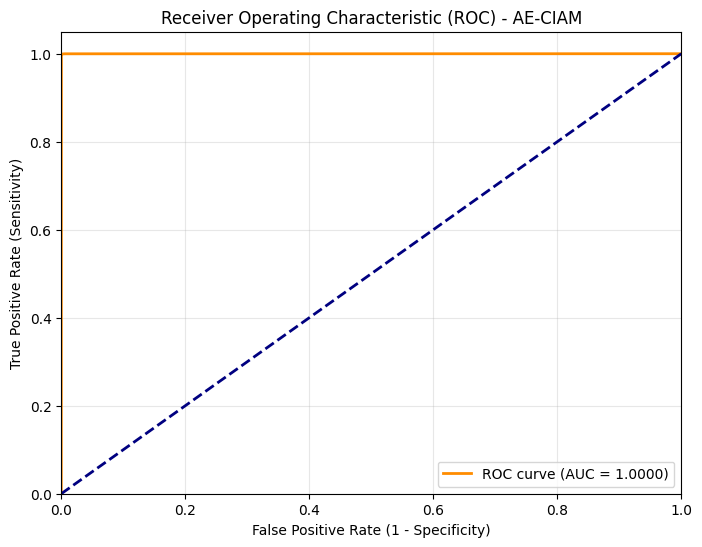

Final AUC Score: 0.99999


In [28]:
from sklearn.metrics import roc_curve, auc

# 1. Get the probability for the "Attack" class (class 1)
# y_pred_probs contains [prob_class_0, prob_class_1]
y_probs_attack = y_pred_probs[:, 1]

# 2. Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_probs_attack)
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - AE-CIAM')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final AUC Score: {roc_auc:.5f}")

In [29]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.5f}")

Matthews Correlation Coefficient (MCC): 0.99615


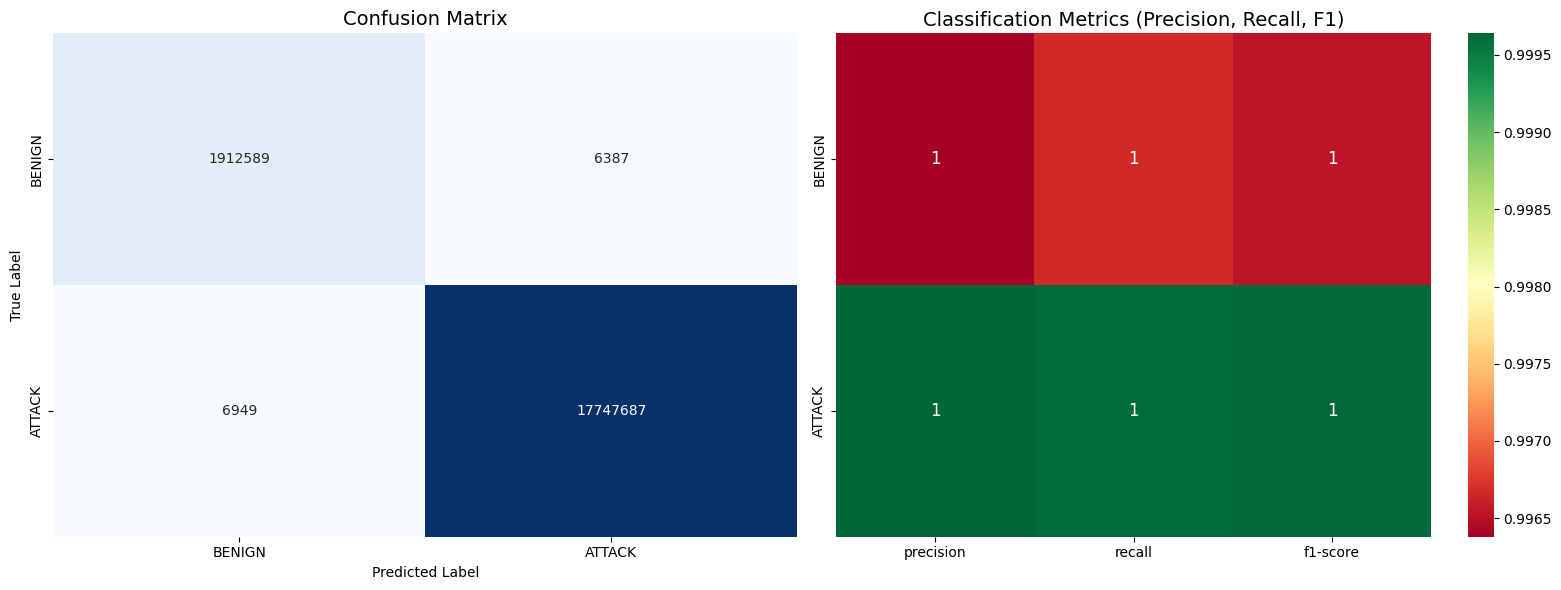

In [30]:
import seaborn as sns
import pandas as pd

# 1. Setup the figure
plt.figure(figsize=(16, 6))

# --- PLOT 1: Confusion Matrix Heatmap ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['BENIGN', 'ATTACK'], 
            yticklabels=['BENIGN', 'ATTACK'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# --- PLOT 2: Classification Report Heatmap ---
plt.subplot(1, 2, 2)
# Generate report as a dictionary to convert to a DataFrame
report_dict = classification_report(y_test, y_pred, 
                                    target_names=['BENIGN', 'ATTACK'], 
                                    output_dict=True)
# Convert to DataFrame and remove 'accuracy' and 'support' for a cleaner heatmap
report_df = pd.DataFrame(report_dict).iloc[:-1, :2].T 

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=True, annot_kws={"size": 12})
plt.title('Classification Metrics (Precision, Recall, F1)', fontsize=14)

plt.tight_layout()
plt.show()

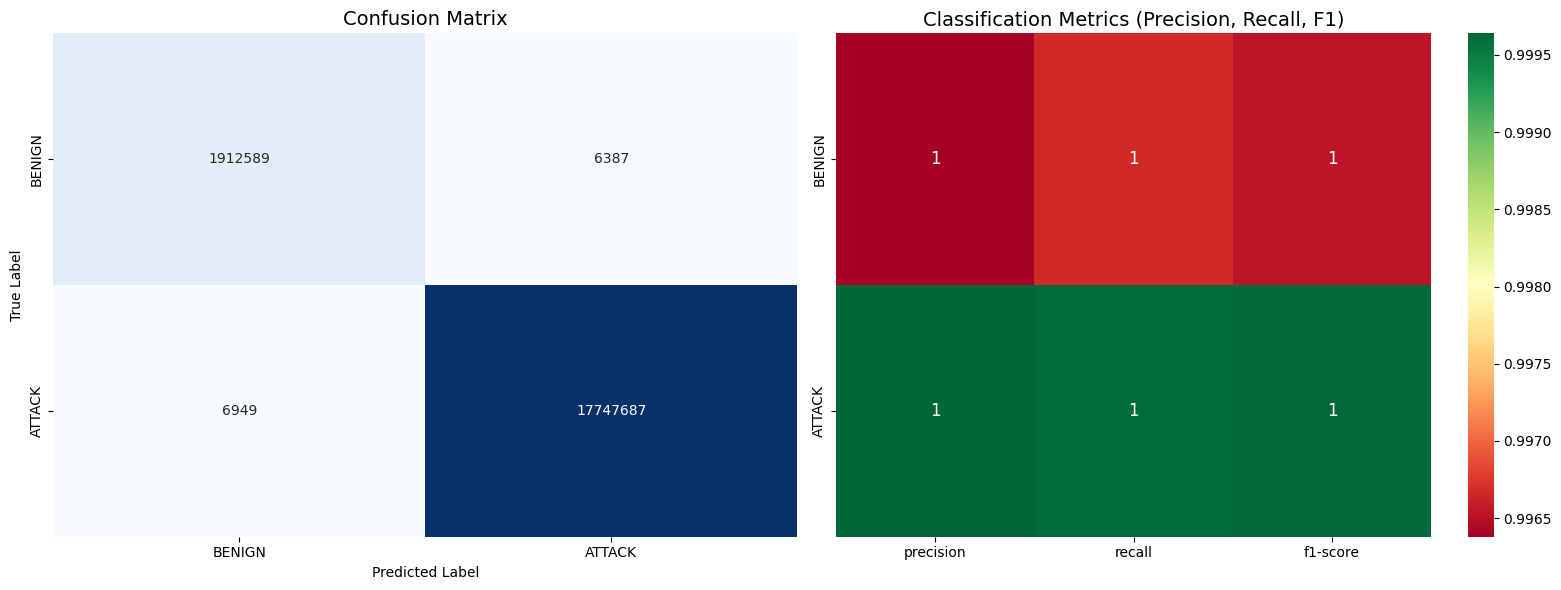

In [31]:
import seaborn as sns
import pandas as pd

# 1. Setup the figure
plt.figure(figsize=(16, 6))

# --- PLOT 1: Confusion Matrix Heatmap ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['BENIGN', 'ATTACK'], 
            yticklabels=['BENIGN', 'ATTACK'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# --- PLOT 2: Classification Report Heatmap ---
plt.subplot(1, 2, 2)
# Generate report as a dictionary to convert to a DataFrame
report_dict = classification_report(y_test, y_pred, 
                                    target_names=['BENIGN', 'ATTACK'], 
                                    output_dict=True)
# Convert to DataFrame and remove 'accuracy' and 'support' for a cleaner heatmap
report_df = pd.DataFrame(report_dict).iloc[:-1, :2].T 

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=True, annot_kws={"size": 12})
plt.title('Classification Metrics (Precision, Recall, F1)', fontsize=14)

plt.tight_layout()
plt.show()